<a href="https://colab.research.google.com/github/corrielynnyuill-debug/FinalProject-CLY/blob/main/FinalProject_CorrieLynnYuill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fianl Project - Corrie Lynn Yuill
Data: IEEE-Fraud_Detection
https://www.kaggle.com/competitions/ieee-fraud-detection/data



Mount Drive and Load datasets using pandas

In [1]:
# Mount drive in Colab
from google.colab import drive
drive.mount('/content/drive')

# Load the datasets
import pandas as pd

# Set file path
DATA_PATH = "/content/drive/MyDrive/FinalProject/"

# Load training data
train_transaction = pd.read_csv(DATA_PATH + "train_transaction.csv")
train_identity = pd.read_csv(DATA_PATH + "train_identity.csv")

# Load Test data
test_transaction = pd.read_csv(DATA_PATH + "test_transaction.csv")
test_identity = pd.read_csv(DATA_PATH + "test_identity.csv")

# Merge Tables on Transaction ID
train_df = train_transaction.merge(train_identity, on='TransactionID', how='left')
test_df = test_transaction.merge(test_identity, on='TransactionID', how='left')

# Reduce Memory Usage
def reduce_memory(df):
  start_mem = df.memory_usage().sum() / 1024**2
  print(f"Memory usage of dataframe is {start_mem:.2f} MB")

  for col in df.columns:
    col_type = df[col].dtype

    if col_type != object:
      c_min = df[col].min()
      c_max = df[col].max()

      if str(col_type)[:3] == "int":
        if c_min > -128 and c_max < 127:
          df[col] = df[col].astype('int8')
        elif c_min > -32768 and c_max < 32767:
          df[col] = df[col].astype('int16')
        elif c_min > -2147483648 and c_max < 2147483647:
          df[col] = df[col].astype('int32')
      else:
        df[col] = df[col].astype('float32')

  end_mem = df.memory_usage().sum() / 1024**2
  print(f"Memory usage after optimization is: {end_mem:.2f} MB")
  print(f"Decreased by {(start_mem - end_mem) / start_mem *100:.1f}%")

  return df


train_df = reduce_memory(train_df)
test_df = reduce_memory(test_df)

Mounted at /content/drive
Memory usage of dataframe is 1955.37 MB
Memory usage after optimization is: 1044.70 MB
Decreased by 46.6%
Memory usage of dataframe is 1673.87 MB
Memory usage after optimization is: 895.89 MB
Decreased by 46.5%


EXploaratory Data Analysis

In [2]:
# General Exploratory Analysis
print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)
print("Training Data Columns:", train_df.columns)
print("Testing Data Columns:", test_df.columns)


Training Data Shape: (590540, 434)
Testing Data Shape: (506691, 433)
Training Data Columns: Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=434)
Testing Data Columns: Index(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'id-31', 'id-32', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=433)


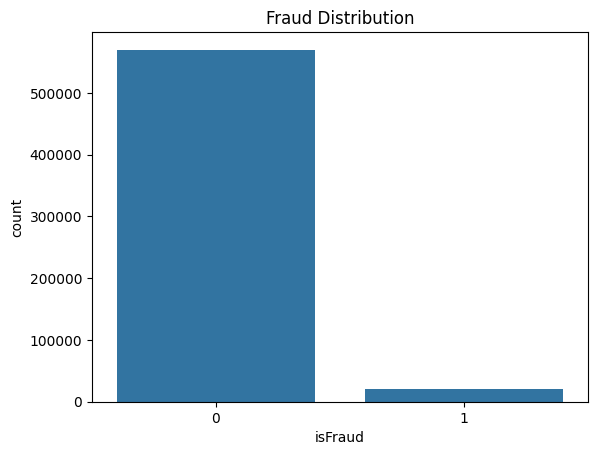

In [3]:
# Fraud distribution Countplot visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=train_df['isFraud'])
plt.title('Fraud Distribution')
plt.show()

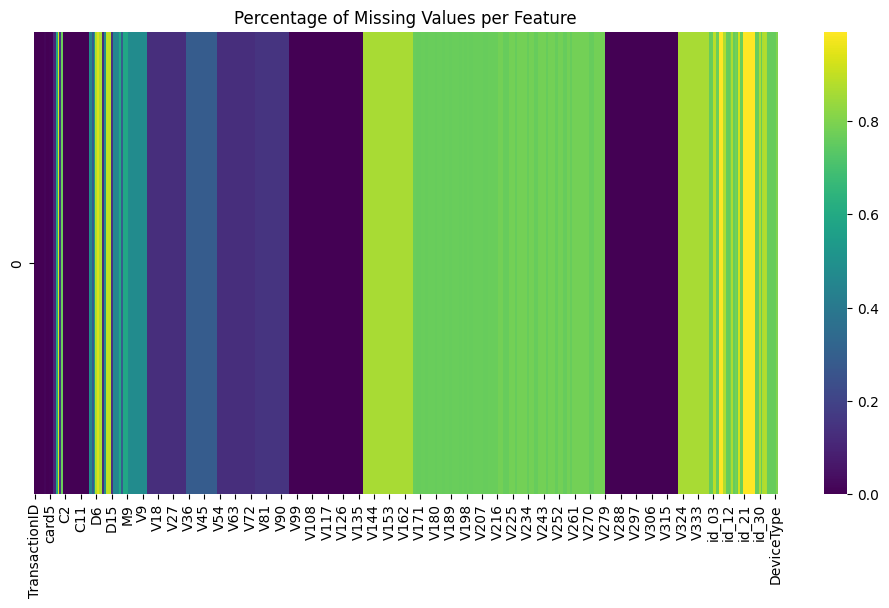

In [4]:
# Heatmap to visualize percentage of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(train_df.isnull().mean().to_frame().T, cmap='viridis')
plt.title('Percentage of Missing Values per Feature')
plt.show()

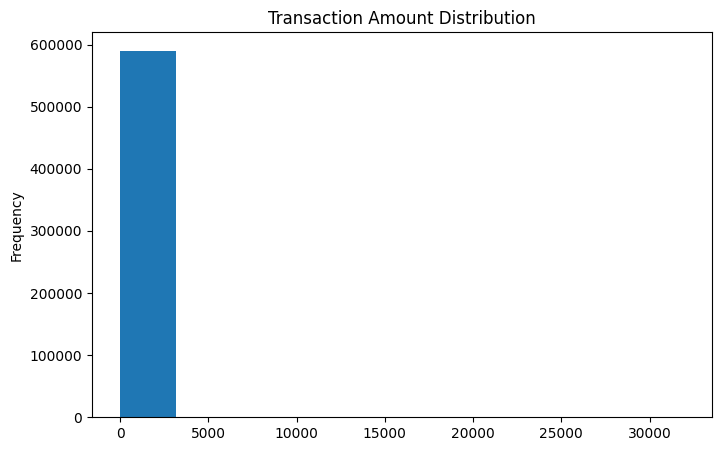

In [5]:
# Transaction Amount Distribution
train_df['TransactionAmt'].plot(kind='hist', bins=10, figsize=(8,5))
plt.title('Transaction Amount Distribution')
plt.show()


isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64


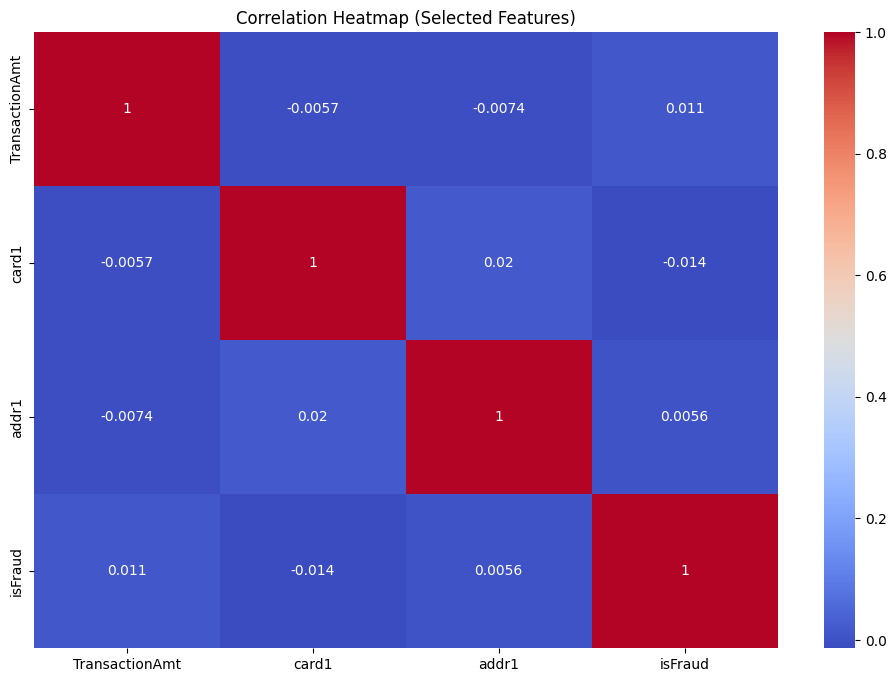

In [6]:
# Correlation with Fraud
numeric_cols = train_df.select_dtypes(
    include=['int8', 'int16', 'int32', 'float32', 'float16', 'float64']
).columns

corr_matrix = train_df[numeric_cols].corr()

print(corr_matrix['isFraud'].sort_values(ascending=False).head(20))

# Correlation Heatmap of Selected Features
plt.figure(figsize=(12, 8))
sns.heatmap(train_df[['TransactionAmt', 'card1', 'addr1', 'isFraud']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Selected Features)')
plt.show()


### Feature Engineering

Fraud detection relies heavily on engineered features that capture behavioral,
temporal, and device-level patterns. The IEEE‑CIS dataset contains many raw
fields that require transformation before they become useful signals.

In this section, we engineer the following feature groups:

1. Time-based features (hour, day, weekday)
2. Email domain grouping (free vs corporate vs risky)
3. Device/browser normalization
4. Card grouping and frequency encoding
5. Address frequency encoding
6. Transaction amount transformations
7. Aggregation features (mean/std/count per card/device/email)

These engineered features are commonly used in real-world fraud detection
systems and significantly improve model performance.

In [7]:
from pandas.core.dtypes.missing import isna
# Time Based features
train_df['hour'] = (train_df['TransactionDT'] // 3600) % 24
train_df['day'] = (train_df['TransactionDT'] // (3600 * 24)) % 7
train_df['weekday'] = train_df['day'] % 7
train_df['is_weekend'] = (train_df['weekday'] >= 5).astype('int8')
train_df['is_night'] = train_df['hour'].isin([0, 1, 2, 3, 4]).astype('int8')

# Email Domain Grouping
email_domains = {
    'gmail.com': 'free',
    'yahoo.com': 'free',
    'hotmail.com': 'free',
    'outlook.com': 'free',
    'icloud.com': 'free'
}

def map_email(x):
  if pd.isna(x):
    return 'unknown'
  x = x.lower()
  if x in email_domains:
    return 'free'
  if 'edu' in x:
    return 'education'
  if 'gov' in x:
    return 'government'
  return 'other'

train_df['P_emaildomain_group'] = train_df['P_emaildomain'].apply(map_email)
train_df['R_emaildomain_group'] = train_df['R_emaildomain'].apply(map_email)

# Device and Browser Normalization
train_df['DeviceInfo'] = train_df['DeviceInfo'].fillna('unknown').str.lower().str.split().str[0]

# Browser normalization
train_df['id_31'] = train_df['id_31'].fillna('unknown').str.lower().str.split().str[0]

# Frequency encoding helper
def frequency_encode(df, col):
  freq = df[col].value_counts()
  return df[col].map(freq)

# Card Grouping and Frequency Encoding
for col in ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']:
  if col in train_df.columns:
    train_df[col + '_freq'] = frequency_encode(train_df, col)

# Address Frequency Encoding
for col in ['addr1', 'addr2']:
  train_df[col + '_freq'] = frequency_encode(train_df, col)

# Email domain group frequency
train_df['P_emaildomain_group_freq'] = frequency_encode(train_df, 'P_emaildomain_group')
train_df['R_emaildomain_group_freq'] = frequency_encode(train_df, 'R_emaildomain_group')

# Transaction Amount Transformations
import numpy as np
train_df['TransactionAmt_log'] = np.log1p(train_df['TransactionAmt'])
train_df['TransactionAmt_log_sq'] = np.sqrt(train_df['TransactionAmt_log'])

# Aggregation Features
for col in ['card1', 'card2', 'addr1']:
  train_df[f'{col}_trans_count'] = train_df.groupby(col)['TransactionID'].transform('count').copy()
  train_df[f'{col}_trans_mean'] = train_df.groupby(col)['TransactionAmt'].transform('mean').copy()
  train_df[f'{col}_trans_std'] = train_df.groupby(col)['TransactionAmt'].transform('std').fillna(0).copy()

# Aggregates for categorical columns
if 'DeviceInfo' in train_df.columns:
  train_df['DeviceInfo_trans_count'] = train_df.groupby('DeviceInfo')['TransactionID'].transform('count')

train_df['P_emaildomain_trans_count'] = train_df.groupby('P_emaildomain')['TransactionID'].transform('count')
train_df['addr2_trans_count'] = train_df.groupby('addr2')['TransactionID'].transform('count')

# Device risk score
train_df['DeviceInfo_risk_score'] = 1 /(1 + train_df['DeviceInfo_trans_count'])

# Defragment and rebuild df
train_df = train_df.copy()


print("The feature engineering pipeline ran without errors.")
print('Final dataset shape:', train_df.shape)

/tmp/ipykernel_22203/736728924.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['hour'] = (train_df['TransactionDT'] // 3600) % 24
/tmp/ipykernel_22203/736728924.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['day'] = (train_df['TransactionDT'] // (3600 * 24)) % 7
/tmp/ipykernel_22203/736728924.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1

The feature engineering pipeline ran without errors.
Final dataset shape: (590540, 466)


### Model Training

With the dataset fully engineered, we now train a supervised fraud detection model
using LightGBM. This model is well-suited for the IEEE‑CIS dataset due to its
ability to handle:

- High-dimensional feature spaces  
- Missing values  
- Non-linear relationships  
- Imbalanced datasets  

We begin by preparing the training data, splitting into train/validation sets,
and fitting a LightGBM classifier. We evaluate performance using AUC, a standard
metric for fraud detection.

In [8]:
# Prepare the Training Data
from sklearn.model_selection import train_test_split

# Target
y = train_df['isFraud']

# Drop target and non-features
drop_cols = ['isFraud', 'TransactionID', 'TransactionDT']
X = train_df.drop(columns=drop_cols, errors='ignore')

# Drop raw categorical columns that cause memory usage blow-up
raw_cat_cols = [
    'ProductCD', 'card4', 'card6',
    'P_emaildomain', 'R_emaildomain',
    'DeviceType', 'DeviceInfo',
    'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29',
    'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'
]
X = X.drop(columns=[c for c in raw_cat_cols if c in X.columns])

# Convert object columns to category dtype
for col in X.columns:
  if X[col].dtype == 'object':
    X[col] = X[col].astype('category')

# Train Validate Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)

# Train a LightGBM Model
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# LightGBM dataset format
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

# Model Parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'max_depth': -1,
    'num_leaves': 64,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

# Train Model
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    num_boost_round=300,
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)



X_train shape: (472432, 432)
X_val shape: (118108, 432)
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[300]	train's auc: 0.979396	valid's auc: 0.955565


Evaluate Model Performance

Validation AUC: 0.9555650493009179


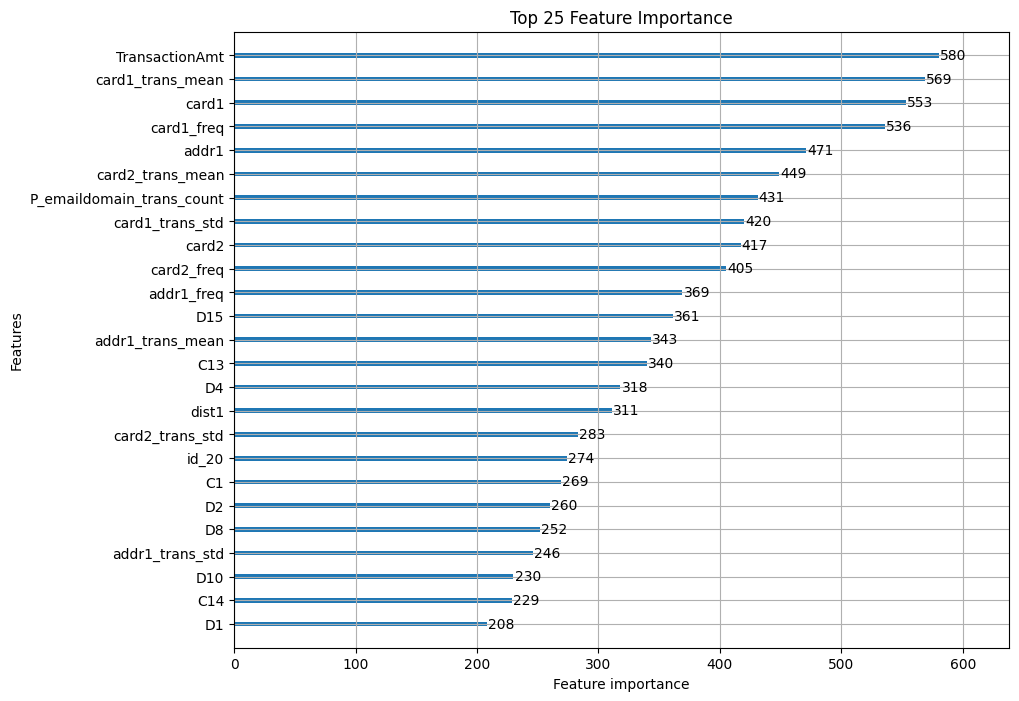

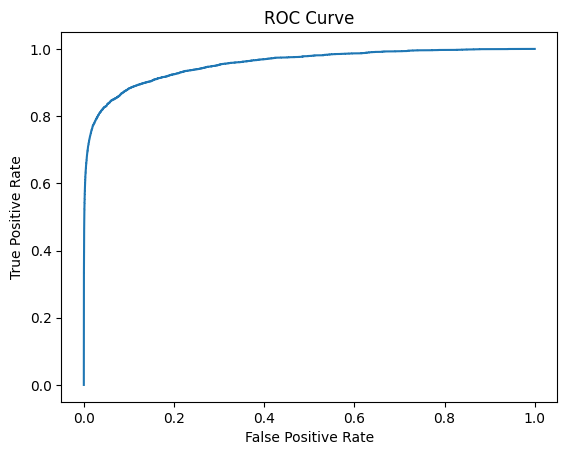

In [9]:
# Predict validation set
val_pred = model.predict(X_val)

# Calculate AUC
auc = roc_auc_score(y_val, val_pred)
print('Validation AUC:', auc)

# Feature Importance Plot
lgb.plot_importance(model, max_num_features=25, figsize=(10, 8))
plt.title('Top 25 Feature Importance')
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_val, val_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


In [10]:
# Prediction Fuction
def predict_fraud(model, rows):
  return model.predict(rows)

predict_fraud(model, X_val.head(10))

array([0.00366523, 0.01036822, 0.0078698 , 0.00174723, 0.00243628,
       0.0140082 , 0.00567021, 0.00113459, 0.00308418, 0.00444352])

### Interactive Prediction Demo
This demo randomly selects a transaction from the validation set using X_val.sample.  
Re-run the cell to explore how the model responds to different transactions.  

In [11]:
# Interactive Demo
def predict_fraud_demo(model, row):
  prob = float(model.predict(row)[0])
  idx = row.index[0]
  txn_id = row.get('TransactionID', 'N/A')
  print(f'Row {idx} | Transaction ID: {txn_id} | Probability of Fraud: {prob*100:.2f}%')
  return prob

sample = X_val.sample(1)
predict_fraud_demo(model, sample)


Row 414113 | Transaction ID: N/A | Probability of Fraud: 0.31%


0.0030808667528873035